# Inventory Demand Forecasting Project

In [1]:
#import labraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn import metrics
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error as mae
from sklearn.linear_model import LinearRegression, Lasso, Ridge

import warnings
warnings.filterwarnings("ignore")

In [2]:
#load the dataset
df= pd.read_csv("inventory.csv")
display(df.head())

,date,store,item,sales
0,01-01-2013,1,1,13
1,02-01-2013,1,1,11
2,03-01-2013,1,1,14
3,04-01-2013,1,1,13
4,05-01-2013,1,1,10


In [3]:
display(df.tail())

,date,store,item,sales
912995,27-12-2017,10,50,63
912996,28-12-2017,10,50,59
912997,29-12-2017,10,50,74
912998,30-12-2017,10,50,62
912999,31-12-2017,10,50,82


In [4]:
#dataset shape
df.shape

(913000, 4)

In [5]:
#check the dataset contains
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype
---  ------  --------------   -----
 0   date    913000 non-null  str  
 1   store   913000 non-null  int64
 2   item    913000 non-null  int64
 3   sales   913000 non-null  int64
dtypes: int64(3), str(1)
memory usage: 27.9 MB


In [6]:
#check the dataset static
df.describe()

,store,item,sales
count,913000.000000,913000.000000,913000.000000
mean,5.500000,25.500000,52.250287
std,2.872283,14.430878,28.801144
min,1.000000,1.000000,0.000000
25%,3.000000,13.000000,30.000000
50%,5.500000,25.500000,47.000000
75%,8.000000,38.000000,70.000000
max,10.000000,50.000000,231.000000


In [7]:
#Feature Engineering
parts=df["date"].str.split("-",n=3,expand=True)
df["day"]=parts[0].astype(int)
df["month"]=parts[1].astype(int)
df["year"]=parts[2].astype(int)
df.head()

,date,store,item,sales,day,month,year
0,01-01-2013,1,1,13,1,1,2013
1,02-01-2013,1,1,11,2,1,2013
2,03-01-2013,1,1,14,3,1,2013
3,04-01-2013,1,1,13,4,1,2013
4,05-01-2013,1,1,10,5,1,2013


In [8]:
# #Whether it is a weekend or weekday
from datetime import datetime 
def weekend_or_weekday(year, month, day): 
    d = datetime(year, month, day) 
    return 1 if d.weekday() > 4 else 0 
df['weekend'] = df.apply(lambda x: weekend_or_weekday(x['year'], x['month'], x['day']), 
axis=1)

In [10]:
#a column which can indicate whether there was any holiday on a particular day or not. 
from datetime import date 
import holidays 
india_holidays = holidays.country_holidays('IN') 
df['holidays'] = df['date'].apply(lambda x: 1 if india_holidays.get(x) else 0)

In [11]:
#let's add some cyclical features. 
df['m1'] = np.sin(df['month'] * (2 * np.pi / 12)) 
df['m2'] = np.cos(df['month'] * (2 * np.pi / 12)) 
df.head() 

,date,store,item,sales,day,month,year,weekend,holidays,m1,m2
0,01-01-2013,1,1,13,1,1,2013,0,0,0.5,0.866025
1,02-01-2013,1,1,11,2,1,2013,0,0,0.5,0.866025
2,03-01-2013,1,1,14,3,1,2013,0,0,0.5,0.866025
3,04-01-2013,1,1,13,4,1,2013,0,0,0.5,0.866025
4,05-01-2013,1,1,10,5,1,2013,1,0,0.5,0.866025


In [12]:
#a column whose value indicates which day of the week it is. 
def which_day(year, month, day): 
    return datetime(year, month, day).weekday() 
df['weekday'] = df.apply(lambda x: which_day(x['year'], x['month'], x['day']), axis=1) 


In [13]:
#Now let's remove the columns which are not useful for us. 
df.drop('date', axis=1, inplace=True) 

In [14]:
# Exploratory Data Analysis 
# EDA analyzes the data using visual techniques. It is used to discover trends, and patterns or to check assumptions with the help of statistical summaries and graphical representations.   
df['store'].nunique(), df['item'].nunique() 

(10, 50)

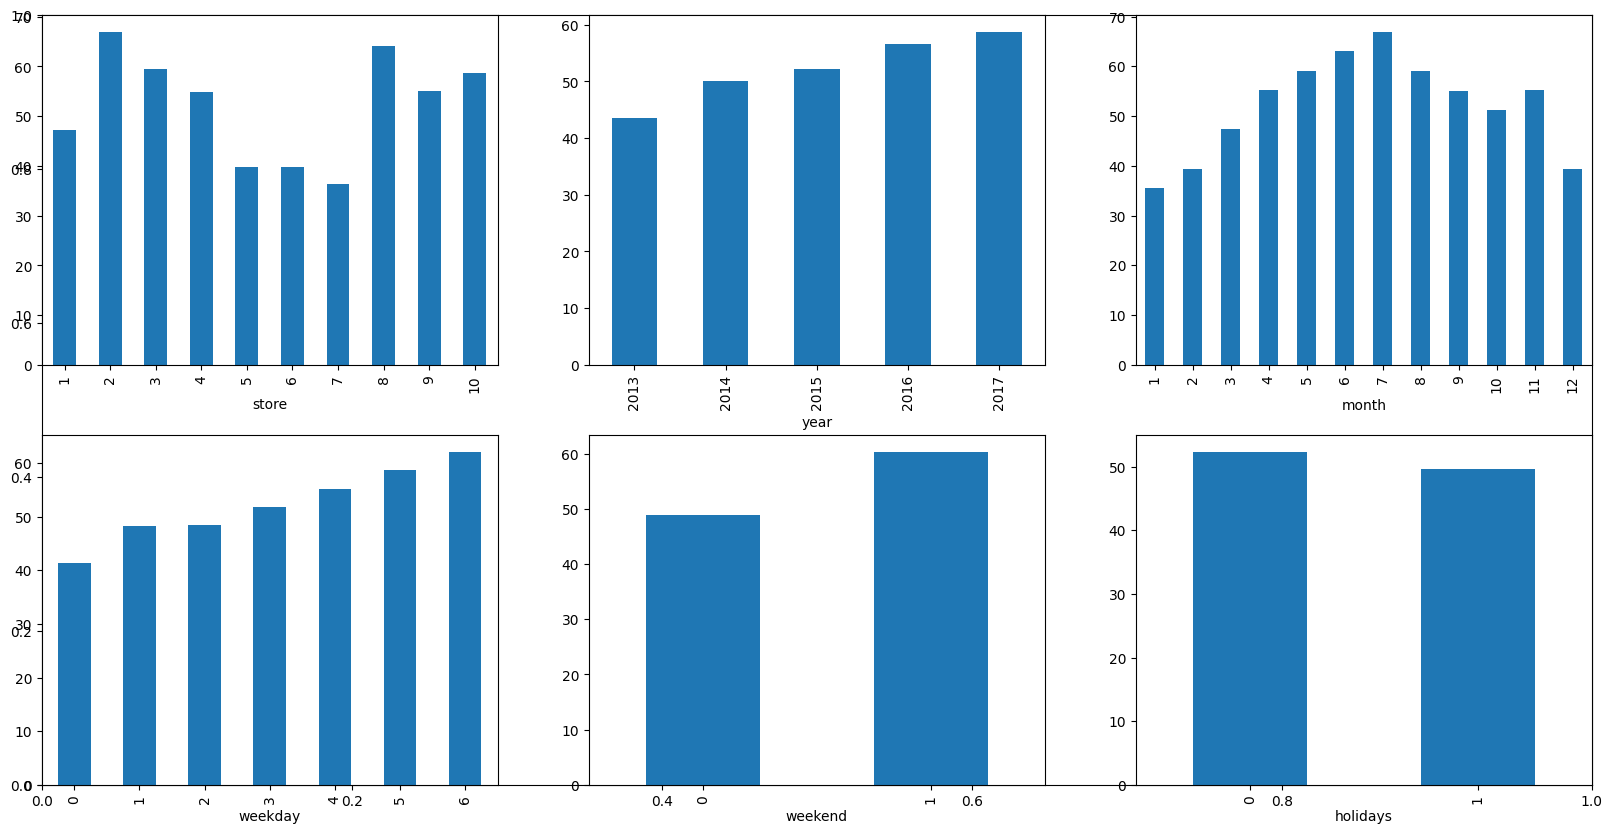

In [15]:
# Now, let's analyze the relationship between various features and sales performance by 
# visualizing. 
# • plt.subplots() is used to creates a figure to accommodate multiple subplots 
# • df.groupby(col).mean()['sales'].plot.bar() groups the data by current column and 
# calculate the mean sales of each group and plot a bar chart to show the averages for 
# each category of features. 
df['weekend'] = df['weekday'].apply(lambda x: 1 if x >= 5 else 0) 
features = ['store', 'year', 'month', 'weekday', 'weekend', 'holidays'] 
plt.subplots(figsize=(20, 10)) 
for i, col in enumerate(features): 
    plt.subplot(2, 3, i + 1) 
    df.groupby(col).mean()['sales'].plot.bar() 
plt.show() 

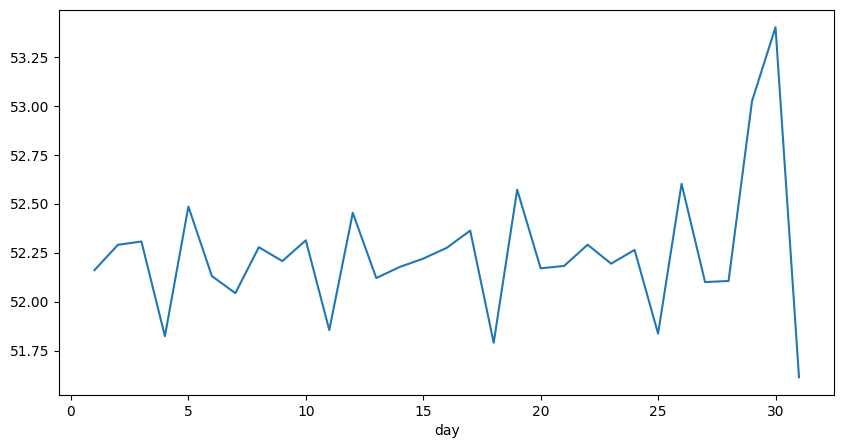

In [16]:
#Now let's check the variation of stock as the month closes to the end using line plot. 
plt.figure(figsize=(10,5)) 
df.groupby('day').mean()['sales'].plot() 
plt.show() 

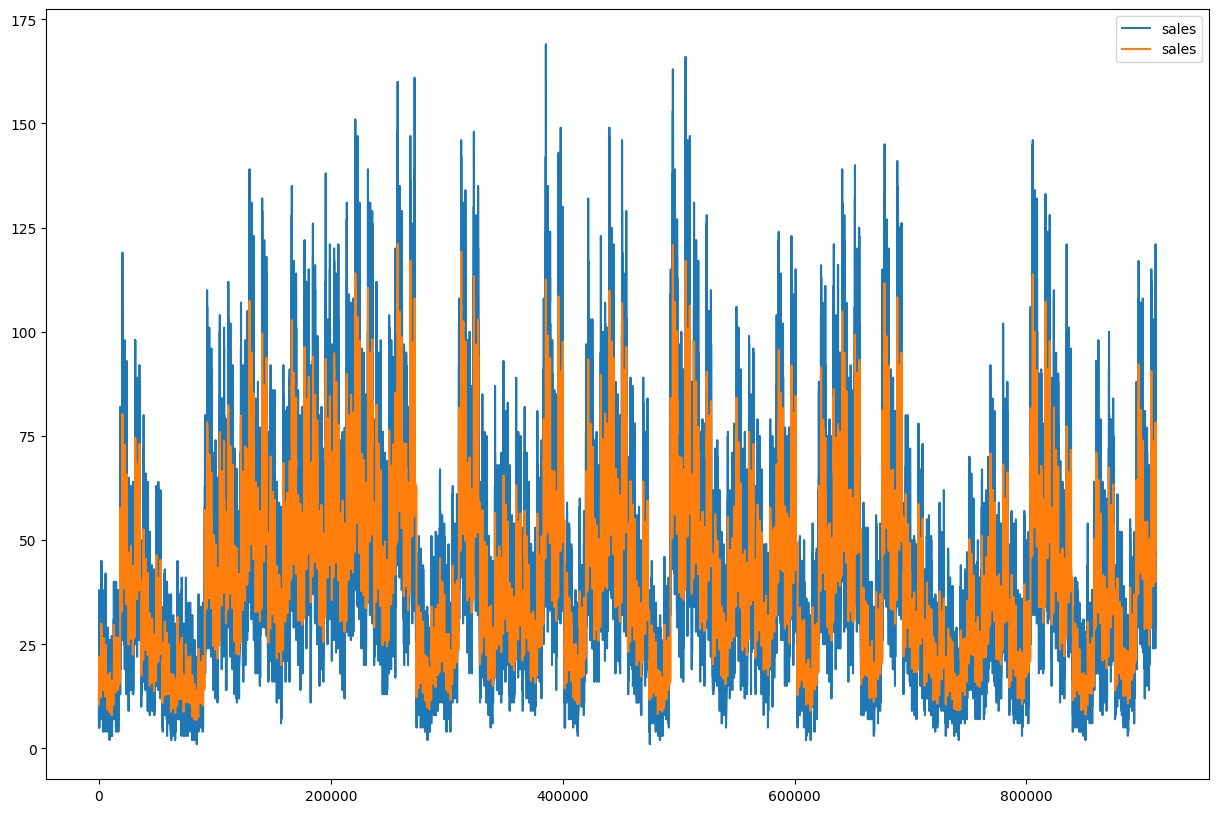

In [17]:
#Let's draw the simple moving average for 30 days period. 
plt.figure(figsize=(15, 10)) 
# Calculating Simple Moving Average  
# for a window period of 30 days 
window_size = 30 
data = df[df['year']==2013] 
windows = data['sales'].rolling(window_size) 
sma = windows.mean() 
sma = sma[window_size - 1:] 
data['sales'].plot() 
sma.plot() 
plt.legend() 
plt.show() 

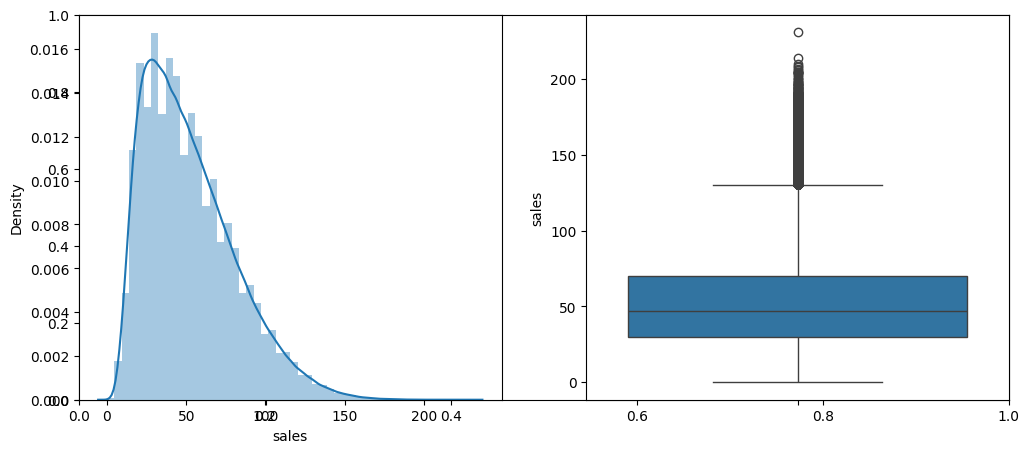

In [18]:
# As the data in the sales column is continuous let's check the distribution of it and check whether there are some outliers in this column or not. 
#We can observe that the distribution is right skewed and the dataset contains outliers. 
plt.subplots(figsize=(12, 5)) 
plt.subplot(1, 2, 1) 
sns.distplot(df['sales']) 
plt.subplot(1, 2, 2) 
sns.boxplot(df['sales']) 
plt.show() 

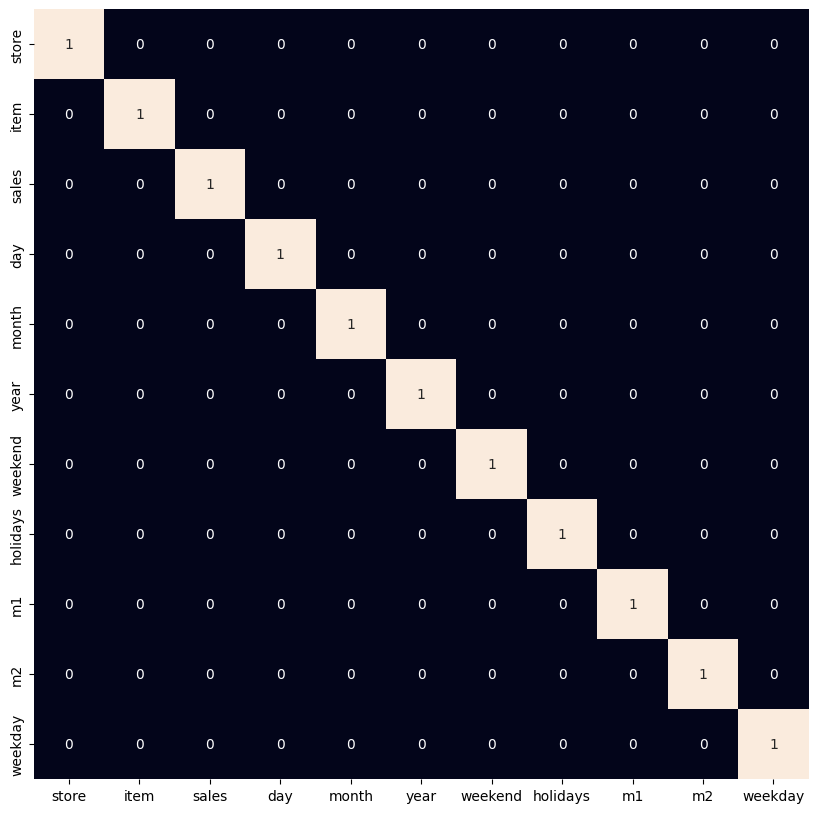

In [19]:
# Now, let's check the correlation between the features of the data and added a filter to 
# identify only the highly correlated features. 
plt.figure(figsize=(10, 10)) 
sns.heatmap(df.corr() > 0.8, 
annot=True, 
cbar=False) 
plt.show() 

In [20]:
#let's remove the outliers which are present in the data. 
df = df[df['sales']<140] 

In [21]:
# Model Training 
# separate the features and target variables and split them into training and the testing data 
features = df.drop(['sales', 'year'], axis=1) 
target = df['sales'].values 
X_train, X_val, Y_train, Y_val = train_test_split(features, target, test_size = 0.05, 
random_state=22) 
X_train.shape, X_val.shape  

((861170, 9), (45325, 9))

In [22]:
# Normalizing the data before feeding it into machine learning models helps us to achieve 
# stable and fast training. 
# Normalizing the features for stable and fast training. 
scaler = StandardScaler() 
X_train = scaler.fit_transform(X_train) 
X_val = scaler.transform(X_val)

In [ ]:
#Now let's train machine learning models and select the best model 
models = [LinearRegression(), XGBRegressor(), Lasso(), Ridge()] 
for i in range(4): 
    models[i].fit(X_train, Y_train) 
    print(f'{models[i]} : ') 
    train_preds = models[i].predict(X_train) 
    print('Training Error : ', mae(Y_train, train_preds)) 
    val_preds = models[i].predict(X_val) 
    print('Validation Error : ', mae(Y_val, val_preds)) 
    print()

LinearRegression() : 
Training Error :  20.902966360303843
Validation Error :  20.97176413121864



In [ ]:
#only for understanding lambda
#a lambda fun that adds 10 to a ginven number
add_ten = lambda x: x+10
print(add_ten(5))

In [ ]:
#only for understandinglambda
#a lambda fun that multiply two argument
multiply=lambda a,b:a*b
print(multiply(5,6))

In [ ]:
#only for understanding lambda
#return 'even' if the number is even, 'odd' otherwise
even_or_odd=lambda x:"Even"if x % 2==0 else "Odd"
print(even_or_odd(7))